In this assignment, we will sequentially practice the steps to build a plagiarism detection application using a pre-trained Word2Vec model.

Data: [Link](https://s3.amazonaws.com/video.udacity-data.com/topher/2019/January/5c4147f9_data/data.zip)

This exercise requires knowledge of Python programming with the following libraries:

    `gensim` (to load the Word2Vec model)
    `numpy` (to compute similarity)

Additionally, we will use a pre-trained Word2Vec model  [Google's pre-trained word2vec model](https://drive.google.com/file/d/0B7XkCwpI5KDYNlNUTTlSS21pQmM/edit?resourcekey=0-wjGZdNAUop6WykTtMip30g)

Steps to Solve This Exercise
- Exploring the Dataset  
- Build a class for computing document similarity (`DocSim` class)
- Create an instance of the above class (Load the pre-trained word embedding model, Create a list of stopwords and create an instance of the `DocSim` class)
- Plagiarism Detection and Evaluation

# Exploring the dataset

As i explored documents the dataset, it has 4 different categories:
- non: no plagiarism, with different type of examples, ideas
- cut: extract sub-sentences, and or combine them together.
- light: use same ideas with modifications, but we can figure out the writing style
- heavy: use same ideas with different types of modifications, such as paraphrase, writting incorrect words intentionally, change example but with same intention, ...

Those documents are evaluated and compared with an "original" document

In [1]:
import os
import gdown
import zipfile
import shutil

# Download files, stored in directory 'data'
data_url = "https://s3.amazonaws.com/video.udacity-data.com/topher/2019/January/5c4147f9_data/data.zip"
data_file_name = "udacity_data.zip"

gdown.download(data_url, data_file_name)

with zipfile.ZipFile(data_file_name) as zip_ref:
  zip_ref.extractall(".")

# Delete zip file
if os.path.exists(data_file_name):
  os.remove(data_file_name)

# Delete Mac files
if os.path.exists('__MACOSX'):
  shutil.rmtree('__MACOSX')

Downloading...
From: https://s3.amazonaws.com/video.udacity-data.com/topher/2019/January/5c4147f9_data/data.zip
To: /content/udacity_data.zip
100%|██████████| 114k/114k [00:00<00:00, 329kB/s]


In [2]:
import pandas as pd

file_path = "data/"
file_info = pd.read_csv(file_path + "file_information.csv")
test_info = pd.read_csv(file_path + "test_info.csv")

In [3]:
file_info

,File,Task,Category
0,g0pA_taska.txt,a,non
1,g0pA_taskb.txt,b,cut
2,g0pA_taskc.txt,c,light
3,g0pA_taskd.txt,d,heavy
4,g0pA_taske.txt,e,non
...,...,...,...
95,orig_taska.txt,a,orig
96,orig_taskb.txt,b,orig
97,orig_taskc.txt,c,orig
98,orig_taskd.txt,d,orig


In [4]:
file_info['Category'].value_counts()

,count
Category,
non,38
cut,19
light,19
heavy,19
orig,5


In [5]:
file_info['Task'].value_counts()

,count
Task,
a,20
b,20
c,20
d,20
e,20


In [6]:
import matplotlib.pyplot as plt
import numpy as np

def plot_task_cat_dist(table, name):

  task_cat = table.groupby('Task')['Category'].value_counts()
  task_cat_df = task_cat.unstack(level='Category')

  # Plotting a stacked bar chart
  task_cat_df.plot(kind='bar', stacked=True, figsize=(10, 6))
  plt.xlabel("Task")
  plt.ylabel("Number of documents")
  plt.title(f"Distribution of documents according to each task and category in {name}")
  plt.xticks(rotation=0)
  plt.legend(title="Category")
  plt.yticks(np.arange(0, 11, 2))
  plt.tight_layout()
  plt.show()


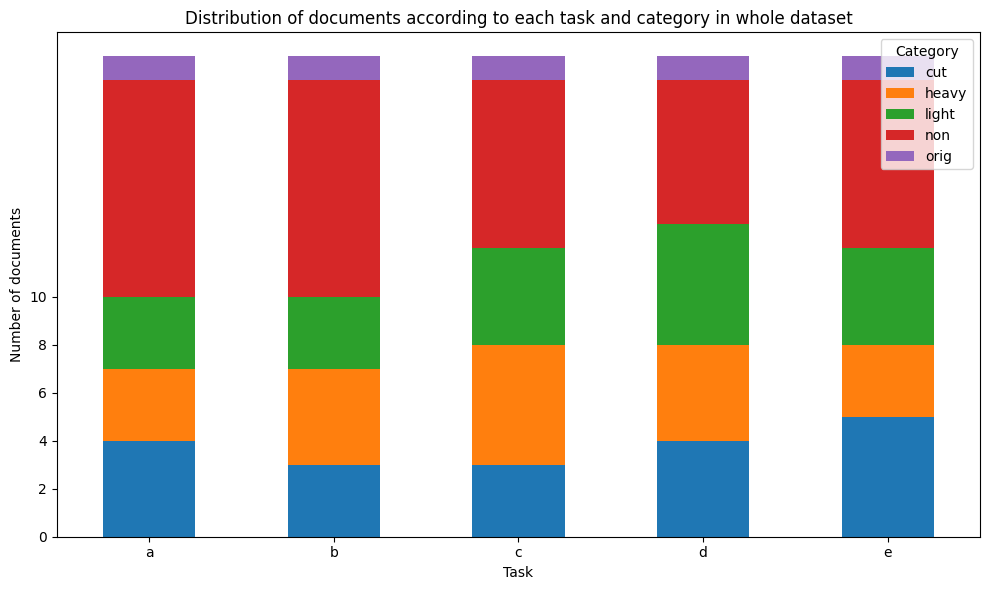

In [7]:
plot_task_cat_dist(file_info, "whole dataset")

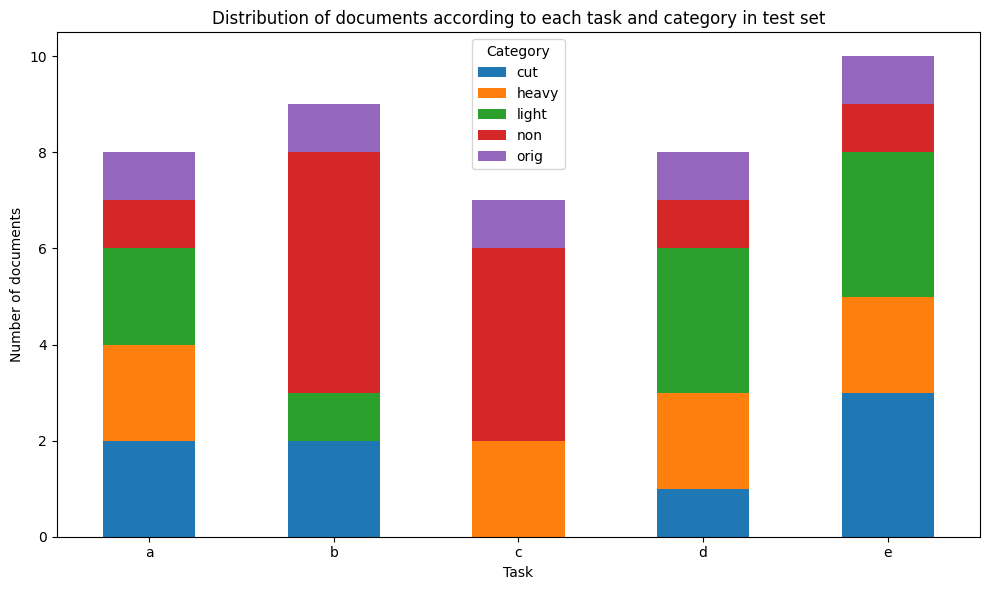

In [8]:
plot_task_cat_dist(test_info, "test set")

The distribution of the whole dataset is quite uniform, but not in test set.

Now, I will add the content of the documents in the dataframe, which are stored in collumn "Text", then convert categories to numerical values: original (0), non (1), cut (2), light (3), and heavy (4), and add train (1) / test (0) label in collumn "Train document?".

In [9]:
whole_text = []

for idx in file_info.index:
  file_name = file_path + file_info.iloc[idx]['File']

  with open(file_name, encoding = "utf-8", errors = "ignore") as file:
    whole_text.append(file.read())

file_info['Text'] = whole_text

In [10]:
# Numerize the label
file_info['Category'] = [0 if label == 'orig' else 1 if label == 'non' else 2 if label == 'cut' else 3 if label == 'light' else 4 for label in file_info.Category]

In [11]:
# Define train/test set
i = 0
j = 0

train_check = [1] * file_info.shape[0]

while i < test_info.shape[0]:
  if file_info.iloc[i]['File'] == test_info.iloc[j]['File']:
    i += 1
    j += 1
    if file_info.iloc[i]['Category'] != 0: # not origin
      train_check[j] = 0
  else:
    i += 1

file_info['Train?'] = train_check

In [12]:
# Ignore file collumn
file_info.drop(columns='File', inplace=True)

In [13]:
file_info.iloc[5]['Text'] # Present a sample after preprocessing

"Inheritance is a basic concept in object oriented programming. It models the reuse of existing class code in new classes – the “is a kind of” relationship.\n\nFor example, a house is a kind of building; similarly, an office block is a kind of building. Both house and office block will inherit certain characteristics from buildings, but also have their own personal characteristics – a house may have a number of occupants, whereas an office block will have a number of offices. However, these personal characteristics don't apply to all types of buildings.\n\nIn this example, the building would be considered the superclass – it contains general characteristics for other objects to inherit – and the house and office block are both subclasses – they are specific types and specialise the characteristics of the superclass.\n\nJava allows object inheritance. When one class inherits from another class, all the public variables and methods are available to the subclass.\n\npublic class Shape {\n

# Build a class for computing document similarity (DocSim class)

In [14]:
from abc import ABC, abstractmethod
import numpy as np

class DocSim(ABC):
  @abstractmethod
  def compute_document_embedding(self, doc):
    pass

  def cosine_similarity(self, emb1, emb2):
    dot_prod = emb1 @ emb2
    emb1_size = np.linalg.norm(emb1)
    emb2_size = np.linalg.norm(emb2)
    return dot_prod / (emb1_size * emb2_size)

  def compare_doc(self, doc1, doc2):
    doc1_emb = self.compute_document_embedding(doc1)
    doc2_emb = self.compute_document_embedding(doc2)
    similarity = self.cosine_similarity(doc1_emb, doc2_emb)
    return similarity

## Averaging method

In [15]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download('punkt_tab')
nltk.download('stopwords')
stop_words = stopwords.words('english')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [16]:
import re

class AvgDocSim(DocSim):
  def __init__(self, w2v_model, stop_words):
    self.w2v_model = w2v_model
    self.stop_words = stop_words

  # Remove uncommon and punctuations
  def preprocess_text(self, text):
    text = re.sub(r"[^a-zA-Z0-9]", " ", text)
    text = re.sub(r"\r", " ", text)
    text = re.sub(r"\t", " ", text)
    text = re.sub("  ", " ", text)

    text = text.lower()

    return text

  # Tokenize and rremove stop words
  def process_text(self, document):
    tokenized_document = word_tokenize(self.preprocess_text(document))
    return [text for text in tokenized_document if text not in self.stop_words]

  # Get embedding
  def compute_document_embedding(self, document):
    tokens = self.process_text(document)
    embs = [self.w2v_model[token] for token in tokens if token in self.w2v_model]

    if not embs:
      return np.zeros(self.w2v_model.vector_size)

    return np.mean(embs, axis = 0)

## Tf-Idf Weighted Averaging Method

Tf-Tdf vectorizer will lowerize the sentence and remove punctuations. So, we don't need to have preprocess method here

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

train_docs = file_info.loc[file_info['Train?'] == 1]['Text'].tolist()

vectorizer = TfidfVectorizer(min_df=1) # Ensure even rare vocabularies can contribute, due to small training set
vectorizer = vectorizer.fit(train_docs)

In [18]:
class TfIdfDocSim(DocSim):
  def __get_w2v_matrix(self):
    vocab = self.tfidf_vectorizer.vocabulary_
    w2v_matrix = np.zeros((len(vocab), self.w2v_model.vector_size))
    for i, word in enumerate(vocab):
      if word in self.w2v_model:
        w2v_matrix[i] = self.w2v_model[word]
    return w2v_matrix

  def __init__(self, w2v_model, tfidf_vectorizer):
    self.w2v_model = w2v_model
    self.tfidf_vectorizer = tfidf_vectorizer
    self.w2v_matrix = self.__get_w2v_matrix()    # All words in the training corpus will have an embedding in the matrix

  def compute_document_embedding(self, document):
    doc_tfidf_vector = self.tfidf_vectorizer.transform([document]) # (1, num_vocab)
    doc_emb = doc_tfidf_vector @ self.w2v_matrix # (1, num_vocab) x (num_vocab, 300) -> (1, 300)
    return np.array(doc_emb).flatten()

# Create an instance of the `Docsim` class

## Loading pre-train Word2Vec model

In [19]:
! pip install gensim
import gdown
from gensim.models import KeyedVectors

model_url = 'https://github.com/mmihaltz/word2vec-GoogleNews-vectors/raw/master/GoogleNews-vectors-negative300.bin.gz'
model_filename = 'GoogleNews-vectors-negative300.bin.gz'

gdown.download(model_url, model_filename, quiet=False)
model = KeyedVectors.load_word2vec_format(model_filename, binary=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 56.4 MB/s eta 0:00:00


Downloading...
From: https://github.com/mmihaltz/word2vec-GoogleNews-vectors/raw/master/GoogleNews-vectors-negative300.bin.gz
To: /content/GoogleNews-vectors-negative300.bin.gz
100%|██████████| 1.65G/1.65G [01:07<00:00, 24.6MB/s]


In [20]:
print(model.most_similar('Plagiarism'))

[('plagiarism', 0.7480090260505676), ('Plagiarizing', 0.5868754386901855), ('Dishonesty', 0.5457892417907715), ('Cheating', 0.5425423383712769), ('academic_dishonesty', 0.5369089841842651), ('plagiarizing', 0.5363924503326416), ('plagiarize', 0.5248656272888184), ('Copyright_Infringement', 0.5228283405303955), ('Censorship', 0.5216426253318787), ('plagarism', 0.5193566083908081)]


## Create an instance of the DocSim class

In [21]:
sample1 = "Object Oriented Programming is a good paradigm for solving complex programming problems"
sample2 = "Object Oriented Programming is a great method to solve hard programming problems"

In [22]:
# Averaging method
avg_docsim = AvgDocSim(model, stop_words)
print(avg_docsim.compare_doc(sample1, sample2))

0.90955


In [23]:
# Tf-IDF Weighted Averaging method
tfidf_docsim = TfIdfDocSim(model, vectorizer)
print(tfidf_docsim.compare_doc(sample1, sample2))

0.6738874759425179


# Plagiarism Detection and Evaluation

## Some statistics

In [24]:
file_info

,Task,Category,Text,Train?
0,a,1,Inheritance is a basic concept of Object-Orien...,1
1,b,2,PageRank is a link analysis algorithm used by ...,0
2,c,3,"The vector space model (also called, term vect...",0
3,d,4,Bayes’ theorem was names after Rev Thomas Baye...,0
4,e,1,Dynamic Programming is an algorithm design tec...,0
...,...,...,...,...
95,a,0,"In object-oriented programming, inheritance is...",1
96,b,0,PageRank is a link analysis algorithm used by ...,1
97,c,0,Vector space model (or term vector model) is a...,1
98,d,0,"In probability theory, Bayes' theorem (often c...",1


In [25]:
origin_text = file_info.iloc[range(-5, 0)]['Text']

In [26]:
origin_text

,Text
95,"In object-oriented programming, inheritance is..."
96,PageRank is a link analysis algorithm used by ...
97,Vector space model (or term vector model) is a...
98,"In probability theory, Bayes' theorem (often c..."
99,"In mathematics and computer science, dynamic p..."


In [27]:
def calculate_similarities(docsim_instance, docsim_name):
  sims = []

  for idx in range(0, len(file_info) - 5):
    task_idx = ord(file_info.iloc[idx]['Task']) - ord('a')
    sim = docsim_instance.compare_doc(file_info.iloc[idx]['Text'], origin_text.iloc[task_idx])
    sims.append(sim)

  sims.extend([1.0] * 5) # For original docs

  file_info[docsim_name] = sims

In [28]:
calculate_similarities(avg_docsim, "AvgDocSim")

In [29]:
calculate_similarities(tfidf_docsim, "TfIdfDocSim")

In [30]:
file_info

,Task,Category,Text,Train?,AvgDocSim,TfIdfDocSim
0,a,1,Inheritance is a basic concept of Object-Orien...,1,0.793344,0.900030
1,b,2,PageRank is a link analysis algorithm used by ...,0,0.966685,0.973010
2,c,3,"The vector space model (also called, term vect...",0,0.985389,0.987842
3,d,4,Bayes’ theorem was names after Rev Thomas Baye...,0,0.857035,0.936477
4,e,1,Dynamic Programming is an algorithm design tec...,0,0.916362,0.905137
...,...,...,...,...,...,...
95,a,0,"In object-oriented programming, inheritance is...",1,1.000000,1.000000
96,b,0,PageRank is a link analysis algorithm used by ...,1,1.000000,1.000000
97,c,0,Vector space model (or term vector model) is a...,1,1.000000,1.000000
98,d,0,"In probability theory, Bayes' theorem (often c...",1,1.000000,1.000000


In [31]:
category_map = {1: 'non', 2: 'cut', 3: 'light', 4: 'heavy'}
train_filtered = file_info[(file_info['Train?'] == 1) & (file_info['Category'] != 0)].copy()
train_filtered['Category_Label'] = train_filtered['Category'].map(category_map)

# Group by Category_Label and calculate descriptive statistics for both methods
stats_comparison = train_filtered.groupby('Category_Label')[['AvgDocSim', 'TfIdfDocSim']].agg(['mean', 'median', 'std'])

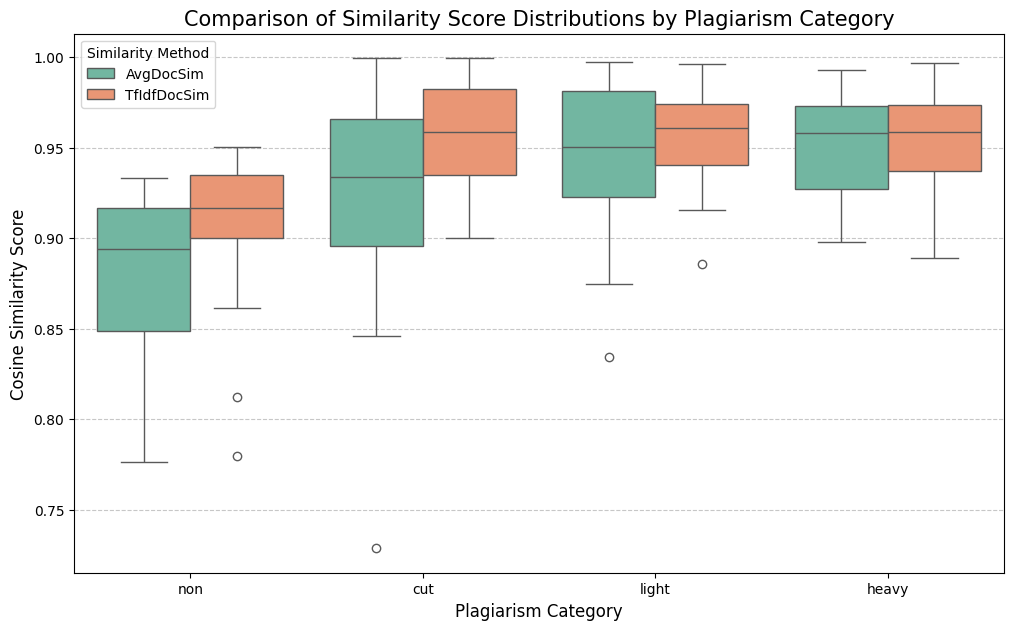

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare data for boxplot by melting the dataframe
plot_df = train_filtered.melt(id_vars=['Category_Label'],
                             value_vars=['AvgDocSim', 'TfIdfDocSim'],
                             var_name='Method',
                             value_name='Similarity_Score')

plt.figure(figsize=(12, 7))
sns.boxplot(x='Category_Label', y='Similarity_Score', hue='Method', data=plot_df, palette='Set2')

plt.title('Comparison of Similarity Score Distributions by Plagiarism Category', fontsize=15)
plt.xlabel('Plagiarism Category', fontsize=12)
plt.ylabel('Cosine Similarity Score', fontsize=12)
plt.legend(title='Similarity Method')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Training model

Because the differences between three plagiarism labels are quite similiar, i group all of these labels into plagiarism. Then, i will those labels to train for the plagiarism detection model

In [33]:
# Numerize the label
file_info['Category'] = [0 if label == 0 else 1 if label == 1 else 2 for label in file_info.Category]

In [34]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import numpy as np

def train_model(model_name, test_full):
  # Filter for training and testing samples, excluding original documents (Category 0)
  train_data = file_info[(file_info['Train?'] == 1) & (file_info['Category'] != 0)]
  test_data = file_info[(file_info['Train?'] == 0) & (file_info['Category'] != 0)]

  # Reshape 1D arrays to 2D arrays as required by sklearn
  X_train = np.array(train_data[model_name]).reshape(-1, 1)
  X_test = np.array(test_data[model_name]).reshape(-1, 1)

  y_train = np.array(train_data['Category'])
  y_test = np.array(test_data['Category'])

  if test_full:
    X_test = np.concatenate((X_train, X_test))
    y_test = np.concatenate((y_train, y_test))

  print(f"----------------------- {model_name} -----------------------")
  model = SVC(probability=True)
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)

  accuracy = accuracy_score(y_test, y_pred)
  print(f"Accuracy: {accuracy}")

  # Get the probability of the positive class (plagiarism)
  if len(model.classes_) > 1:
    probabilities = model.predict_proba(X_test)[:, 1]
    print(f"Probabilities: {probabilities}")

In [35]:
def test(test_full):
  train_model('AvgDocSim', test_full)
  train_model('TfIdfDocSim', test_full)

In [36]:
test(False)

----------------------- AvgDocSim -----------------------
Accuracy: 0.8333333333333334
Probabilities: [0.90438544 0.88414288 0.2584323  0.54086749 0.23483512 0.73188648
 0.86872062 0.90438594 0.90312209 0.71641498 0.28244212 0.33057556]
----------------------- TfIdfDocSim -----------------------
Accuracy: 1.0
Probabilities: [0.92422882 0.89775679 0.65092925 0.18189986 0.21114972 0.35355033
 0.88331557 0.92584209 0.92632066 0.747921   0.19401684 0.1810774 ]


In [37]:
test(True)

----------------------- AvgDocSim -----------------------
Accuracy: 0.8
Probabilities: [0.21949074 0.77521922 0.64558453 0.90487327 0.2581586  0.89870424
 0.26296558 0.26299085 0.85351838 0.70458998 0.26308088 0.27158848
 0.26460115 0.25827874 0.68827414 0.88092847 0.79937666 0.55969261
 0.24207367 0.3593002  0.89220614 0.68185475 0.87055236 0.88743258
 0.31774603 0.34014803 0.25907542 0.66756513 0.27385632 0.89910225
 0.85548268 0.27393546 0.58493048 0.26033791 0.77232205 0.9039347
 0.88114916 0.90452229 0.85831038 0.72510456 0.31303373 0.47447142
 0.75106909 0.88089691 0.42552654 0.69103269 0.34940944 0.72738294
 0.25952505 0.90305071 0.88561676 0.84703408 0.55160482 0.30628034
 0.76797426 0.89839566 0.26520806 0.68878046 0.73024675 0.72437908
 0.26347209 0.84717743 0.2660597  0.26027314 0.37658063 0.90498728
 0.89265276 0.88738607 0.85025323 0.49436594 0.46819498 0.86654834
 0.90197431 0.86338306 0.26407285 0.61094603 0.27399792 0.89675923
 0.33840615 0.90422327 0.65493005 0.2234010

The result is quite exploding:v

Even though averaging method perform slightly better than the tf-idf method in whole dataset, which means it learn better. But, the tf-idf ourperforms it in the test set, demonstrating the robustness of the method.

This is may be because the tf-idf give higher weights on rare words, which is hard to occur simultaneously in two diferrent documents.